# Week 8 — Sentiment Analysis on Product Reviews

**Goal:** Build an NLP pipeline that preprocesses customer review text, trains a sentiment
classification model, and predicts sentiment (Positive / Negative) for new, unseen reviews.

**Note on the rating vs. text question:** the dataset includes a `rating` column (1-5 stars),
but that is only used to *derive the label* for each review during dataset creation
(rating >= 4 -> Positive, rating <= 2 -> Negative). The model itself is trained ONLY on the
review **text** and predicts sentiment from text — that's what "predict sentiment for new
reviews" means, and it's why we can feed it brand-new sentences like *"Product is amazing"*
that have no rating attached at all.

### Pipeline steps
1. Load the reviews dataset (`reviews.csv`)
2. Preprocess the text (lowercase, remove punctuation/numbers, remove stopwords)
3. Convert text to numeric features with TF-IDF
4. Train a classifier (Logistic Regression) on the text features
5. Evaluate the model on a held-out test set
6. Predict sentiment for new, unseen reviews


## 1. Import libraries

In [31]:
import pandas as pd
import numpy as np
import re
import string

from sklearn.model_selection import train_test_split
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import matplotlib.pyplot as plt

pd.set_option('display.max_colwidth', 100)


## 2. Load the dataset

The dataset `reviews.csv` has three columns:
- `review`: the raw customer review text
- `sentiment`: the target label (Positive / Negative)
- `rating`: the original 1-5 star rating (kept only for reference / EDA, **not** used as a model input)

In [32]:
df = pd.read_csv('reviews.csv')
print("Shape:", df.shape)
df.head(10)


Shape: (300, 3)


,review,sentiment,rating
0,"Top notch camera, sturdy, stylish, and easy to use.",Positive,5
1,"Best camera I have ever owned, worth every penny.",Positive,5
2,"Very satisfied customer here, this phone is outstanding.",Positive,4
3,"This jacket is reliable, comfortable, and simply amazing.",Positive,5
4,"I regret buying this tablet, it stopped working within a week.",Negative,2
5,"I am so happy with this headphones, it arrived quickly and works great.",Positive,4
6,The backpack stopped functioning properly after minimal use.,Negative,1
7,"Very satisfied customer here, this bottle is outstanding.",Positive,4
8,"This shoes is amazing, exceeded all my expectations!",Positive,5
9,"Terrible quality watch, not worth the price at all.",Negative,2


In [33]:
# Check class balance
df['sentiment'].value_counts()

sentiment
Positive    150
Negative    150
Name: count, dtype: int64

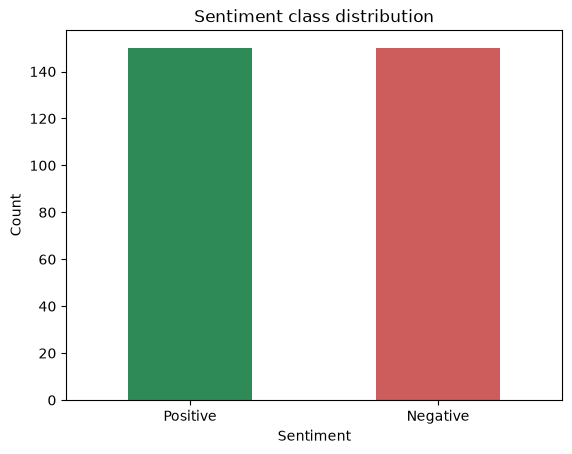

In [34]:
df['sentiment'].value_counts().plot(kind='bar', color=['seagreen', 'indianred'])
plt.title('Sentiment class distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()


## 3. Preprocess the text

Standard NLP text-cleaning steps:
1. Lowercase everything
2. Remove punctuation and numbers
3. Remove extra whitespace
4. Remove common English stopwords (a lightweight built-in list is used here so the
   notebook runs without needing an internet connection to download NLTK data —
   feel free to swap in `nltk.corpus.stopwords` if you have it available)


In [35]:
stop_words = stopwords.words('english')
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()                                  # lowercase
    text = re.sub(r'[^a-z\s]', ' ', text)                      # remove punctuation & numbers
    text = re.sub(r'\s+', ' ', text).strip()                   # collapse whitespace
    tokens = [lemmatizer.lemmatize(w,pos='v') for w in text.split() if w not in stop_words and len(w) > 1]
    return ' '.join(tokens)

df['clean_review'] = df['review'].apply(preprocess_text)
df[['review', 'clean_review']].head(10)


,review,clean_review
0,"Top notch camera, sturdy, stylish, and easy to use.",top notch camera sturdy stylish easy use
1,"Best camera I have ever owned, worth every penny.",best camera ever own worth every penny
2,"Very satisfied customer here, this phone is outstanding.",satisfy customer phone outstanding
3,"This jacket is reliable, comfortable, and simply amazing.",jacket reliable comfortable simply amaze
4,"I regret buying this tablet, it stopped working within a week.",regret buy tablet stop work within week
5,"I am so happy with this headphones, it arrived quickly and works great.",happy headphones arrive quickly work great
6,The backpack stopped functioning properly after minimal use.,backpack stop function properly minimal use
7,"Very satisfied customer here, this bottle is outstanding.",satisfy customer bottle outstanding
8,"This shoes is amazing, exceeded all my expectations!",shoe amaze exceed expectations
9,"Terrible quality watch, not worth the price at all.",terrible quality watch worth price


## 4. Split into train / test sets

In [36]:
X = df['clean_review']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


Train size: 240
Test size: 60


## 5. Feature extraction — TF-IDF vectorization

Converts the cleaned text into numeric feature vectors based on term frequency–inverse document frequency.

In [37]:
vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF feature matrix shape (train):", X_train_tfidf.shape)


TF-IDF feature matrix shape (train): (240, 578)


## 6. Train the sentiment classification model

We use Logistic Regression, a strong and fast baseline for text classification. A Multinomial Naive Bayes model is also trained below for comparison.

In [38]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_tfidf, y_train)

print("Models trained successfully.")


Models trained successfully.


## 7. Evaluate the model

In [39]:
y_pred = model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
print(f"Logistic Regression Accuracy: {acc:.2%}\n")
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Logistic Regression Accuracy: 100.00%

Classification Report:

              precision    recall  f1-score   support

    Negative       1.00      1.00      1.00        30
    Positive       1.00      1.00      1.00        30

    accuracy                           1.00        60
   macro avg       1.00      1.00      1.00        60
weighted avg       1.00      1.00      1.00        60



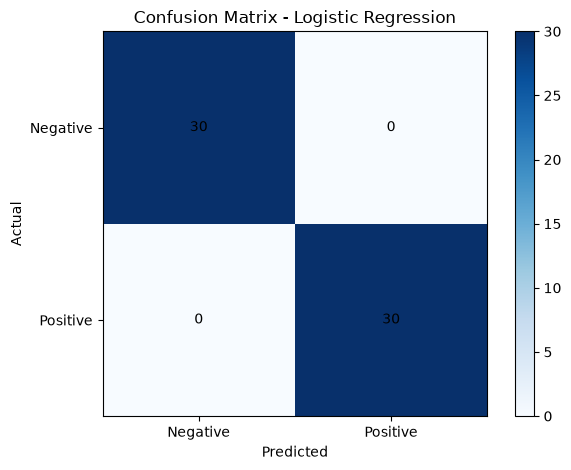

In [40]:
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap='Blues')
ax.set_xticks(range(len(model.classes_)))
ax.set_yticks(range(len(model.classes_)))
ax.set_xticklabels(model.classes_)
ax.set_yticklabels(model.classes_)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Logistic Regression')

for i in range(len(model.classes_)):
    for j in range(len(model.classes_)):
        ax.text(j, i, cm[i, j], ha='center', va='center', color='black')

plt.colorbar(im)
plt.tight_layout()
plt.show()


## 8. Predict sentiment for new reviews

This is the core deliverable: given a **brand-new review sentence** (no rating attached),
run it through the same preprocessing + TF-IDF pipeline and use the trained model to predict
whether it's Positive or Negative.


In [41]:
def predict_sentiment(text, clf=model):
    cleaned = preprocess_text(text)
    vec = vectorizer.transform([cleaned])
    prediction = clf.predict(vec)[0]
    proba = clf.predict_proba(vec)[0]
    classes = clf.classes_
    confidence = dict(zip(classes, proba))
    return prediction, confidence

# Deliverable examples
examples = [
    "Product is amazing",
    "Worst experience",
    "The delivery was fast and the packaging was excellent",
    "I want my money back, this thing is garbage",
    "Not bad, does the job as expected",
    "Absolutely terrible customer support, never buying again",
    "Five stars, would recommend to all my friends",
]

for review in examples:
    pred, conf = predict_sentiment(review)

    print("\n" + "=" * 70)
    print(f"📝 Review     : {review}")
    print(f"🎯 Sentiment  : {pred.capitalize()}")
    print("-" * 70)

    for label, prob in conf.items():
        print(f"{label:<12}: {prob:.2%}")

    print("=" * 70)



📝 Review     : Product is amazing
🎯 Sentiment  : Positive
----------------------------------------------------------------------
Negative    : 45.69%
Positive    : 54.31%

📝 Review     : Worst experience
🎯 Sentiment  : Negative
----------------------------------------------------------------------
Negative    : 62.78%
Positive    : 37.22%

📝 Review     : The delivery was fast and the packaging was excellent
🎯 Sentiment  : Positive
----------------------------------------------------------------------
Negative    : 38.63%
Positive    : 61.37%

📝 Review     : I want my money back, this thing is garbage
🎯 Sentiment  : Negative
----------------------------------------------------------------------
Negative    : 70.52%
Positive    : 29.48%

📝 Review     : Not bad, does the job as expected
🎯 Sentiment  : Negative
----------------------------------------------------------------------
Negative    : 64.22%
Positive    : 35.78%

📝 Review     : Absolutely terrible customer support, never buying 